# Netflix Dataset Analysis
# AnalystLab Africa Data Analytics Internship
# Project Objective
The objective of this project is to clean, validate, transform, and analyze Netflix's content catalogue to understand content composition, geographic distribution, release trends, audience targeting, and genre strategy.

# 1. Import Required Libraries and Load the Datasets

In [1]:
import sys
print(sys.executable)

C:\Users\SAMSUNG\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv", encoding = "ISO-8859-1")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 2. Dataset Overview

In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


# 3. Data Validation

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df["country"].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [10]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [11]:
df["director"].value_counts().head(10)

director
Rajiv Chilaka              19
RaÃºl Campos, Jan Suter    18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
Cathy Garcia-Molina        13
Youssef Chahine            12
Martin Scorsese            12
Jay Chapman                12
Steven Spielberg           11
Name: count, dtype: int64

In [12]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [13]:
df["listed_in"].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

In [14]:
df[df["director"].isnull()][:20]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...
17,s18,TV Show,Falsa identidad,NaN,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
19,s20,TV Show,Jaguar,NaN,"Blanca SuÃ¡rez, IvÃ¡n Marcos, Ãscar Casas, Ad...",NaN,"September 22, 2021",2021,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","In the 1960s, a Holocaust survivor joins a gro..."
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan DÃ¼zyatan, Serdar GÃ¶khan, HÃ¼lya ...",Turkey,"September 22, 2021",2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...
25,s26,TV Show,Love on the Spectrum,NaN,Brooke Satchwell,Australia,"September 21, 2021",2021,TV-14,2 Seasons,"Docuseries, International TV Shows, Reality TV",Finding love can be hard for anyone. For young...


In [15]:
df[df["title"]== "Sex Education"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
32,s33,TV Show,Sex Education,NaN,"Asa Butterfield, Gillian Anderson, Ncuti Gatwa...",United Kingdom,"September 17, 2021",2020,TV-MA,3 Seasons,"British TV Shows, International TV Shows, TV C...",Insecure Otis has all the answers when it come...


In [16]:
df[df["director"].isnull()]["type"].value_counts()

type
TV Show    2446
Movie       188
Name: count, dtype: int64

In [17]:
df[df["date_added"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Ã...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason SaldaÃ±a, Gustavo Sorola, ...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [18]:
df[df["cast"].isnull()]["type"].value_counts()

type
Movie      475
TV Show    350
Name: count, dtype: int64

In [19]:
df["release_year"].value_counts()[:15]

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
2010     194
2011     185
2009     152
2008     136
2006      96
Name: count, dtype: int64

In [20]:
df["date_added"].value_counts()[:20]

date_added
January 1, 2020      109
November 1, 2019      89
March 1, 2018         75
December 31, 2019     74
October 1, 2018       71
July 1, 2021          60
October 1, 2019       60
November 1, 2018      60
September 1, 2021     56
July 1, 2019          52
January 1, 2018       52
June 2, 2021          51
January 1, 2021       49
October 1, 2017       47
April 1, 2018         44
April 1, 2020         43
May 1, 2018           41
July 1, 2018          40
July 6, 2021          39
August 1, 2017        39
Name: count, dtype: int64

# Data Cleaning and Feature Engineering


In [21]:
clean_df = df.copy()

In [22]:
clean_df["description"] = clean_df["description"].str.strip()

In [23]:
clean_df["date_added"] = pd.to_datetime(
    clean_df["date_added"],
    errors="coerce"
)

In [24]:
clean_df["year"] = clean_df["date_added"].dt.year

In [25]:
clean_df["month"] = clean_df["date_added"].dt.month_name()

In [26]:
clean_df["day"] = clean_df["date_added"].dt.day_name()

In [27]:
saved_df = clean_df.copy()

In [48]:
saved_df.to_csv("Netflix_Data_Analysis_Saved_Clean_v1.csv", index=False)

# Explorative Data Analysis

1. what product type dominate Netflix?

In [28]:
saved_df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

There are more MOVIES than TV SHOWS on Netflix

2. Which Countries have more contents on Netflix?

In [29]:
country_df = saved_df.assign(
    country = saved_df["country"].str.split(",")
).explode("country")

In [30]:
country_df["country"] = country_df["country"].str.strip()

In [31]:
country_df["country"].value_counts()[:10]

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

country:
United States                                    3690;
India                                             1046;
United Kingdom                                    806;
Canada                                            445;
France                                            393;
top the list



3. Which Directors have the most products on Netflix?

In [32]:
saved_df["director"].value_counts()[:10]

director
Rajiv Chilaka              19
RaÃºl Campos, Jan Suter    18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
Cathy Garcia-Molina        13
Youssef Chahine            12
Martin Scorsese            12
Jay Chapman                12
Steven Spielberg           11
Name: count, dtype: int64

director:
Rajiv Chilaka              19;
RaÃºl Campos, Jan Suter    18;
Suhas Kadav                16;
Marcus Raboy               16;
Jay Karas                  14
Top the list

4. What years were products added the most on Netflix?

In [33]:
saved_df["year"].value_counts().head(10)

year
2019.0    1999
2020.0    1878
2018.0    1625
2021.0    1498
2017.0    1164
2016.0     418
2015.0      73
2014.0      23
2011.0      13
2013.0      10
Name: count, dtype: int64

5. what movie ratings dominate Netflix

In [34]:
saved_df["rating"].value_counts()[:7]

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
Name: count, dtype: int64

6. Which Genre are contents Listed in the most

In [35]:
genre_df = saved_df.assign(
    genre = saved_df["listed_in"].str.split(",")
).explode("genre")

In [36]:
genre_df["genre"] = genre_df["genre"].str.strip()

In [37]:
 genre_df["genre"].value_counts().head(10)

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64



# DATA VISUALIZATION

Chart 1: Movies vs TV Shows
Business Question

What type of content dominates Netflix?

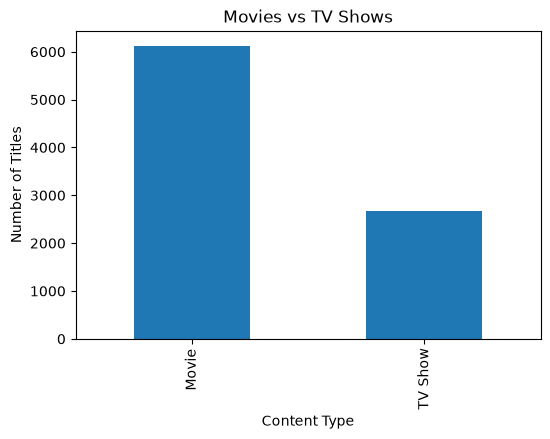

In [38]:
content_type = saved_df["type"].value_counts()

content_type.plot(
    kind="bar",
    figsize=(6,4),
    title="Movies vs TV Shows"
)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

Chart 2: Top 10 Countries

Business Question:

Which countries contribute the most content to Netflix?

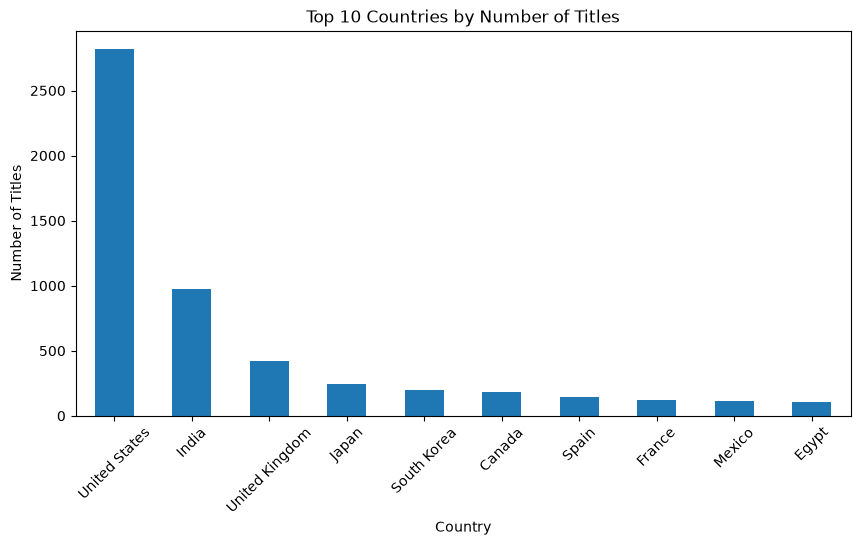

In [39]:
top_countries = (
    saved_df["country"]
    .value_counts()
    .head(10)
)

top_countries.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Countries by Number of Titles"
)

plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

Chart 3: Content Added Per Year

Business Question:

How has Netflix expanded its catalogue over time?

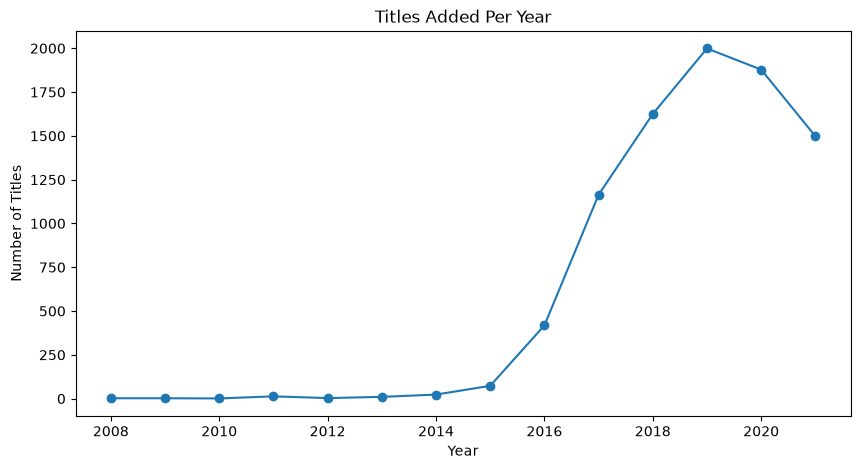

In [40]:
titles_per_year = (
    saved_df["year"]
    .value_counts()
    .sort_index()
)

titles_per_year.plot(
    kind="line",
    figsize=(10,5),
    marker="o",
    title="Titles Added Per Year"
)

plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Chart 4: Rating Distribution

Business Question:

What audience does Netflix mainly target?

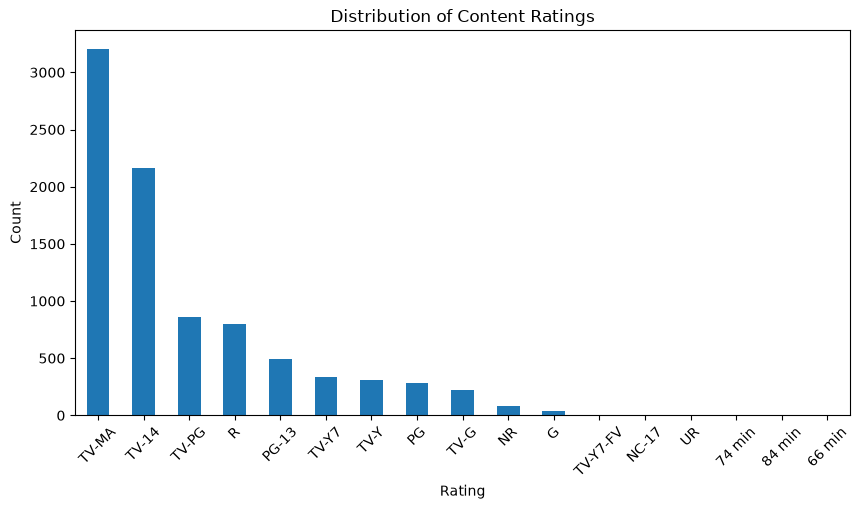

In [41]:
ratings = (
    saved_df["rating"]
    .value_counts()
)

ratings.plot(
    kind="bar",
    figsize=(10,5),
    title="Distribution of Content Ratings"
)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Chart 5: Top Genres

If you've already split or exploded the listed_in column, use this:

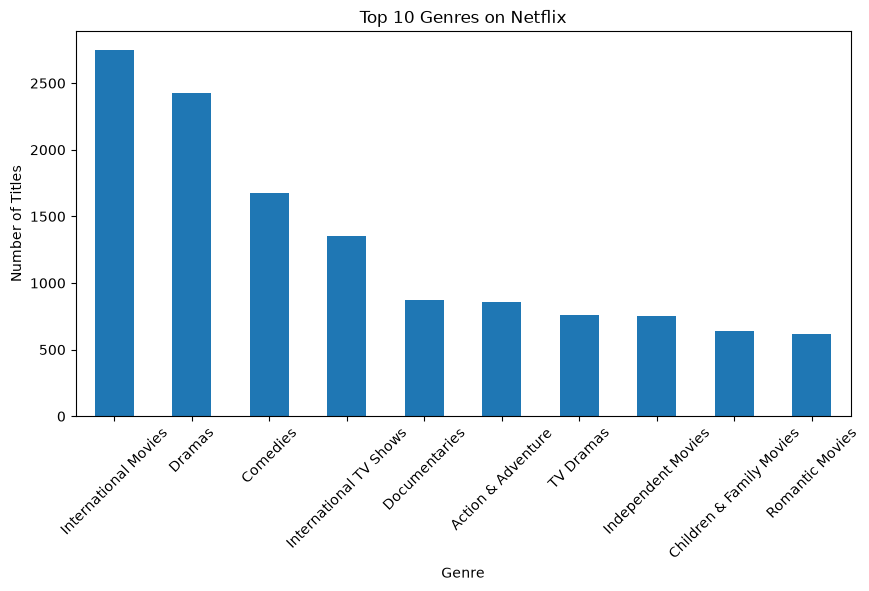

In [42]:
genres = (
    saved_df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

genres.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Genres on Netflix"
)

plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

Chart 6: Movies vs TV Shows Over Time

This is an excellent chart for demonstrating analytical thinking.

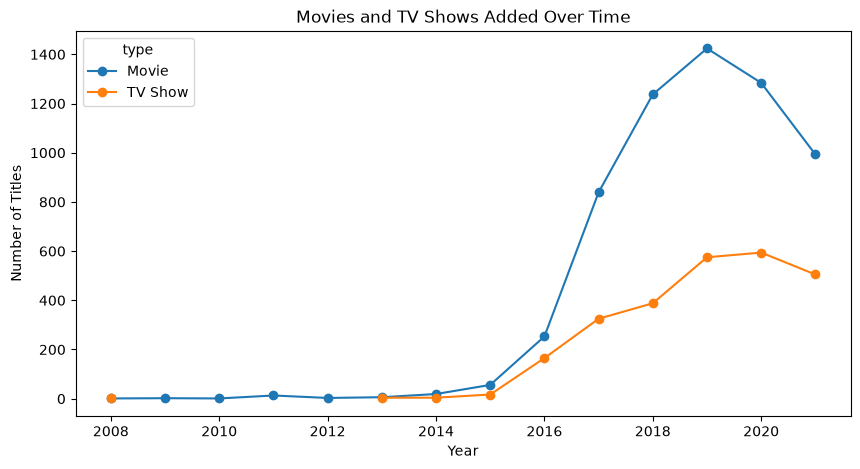

In [43]:
content_year = (
    saved_df
    .groupby(["year","type"])
    .size()
    .unstack()
)

content_year.plot(
    figsize=(10,5),
    marker="o",
    title="Movies and TV Shows Added Over Time"
)

plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

# Executive Summary
# Netflix Content Analysis (2021 Dataset)
Project Objective

The objective of this project was to explore Netflix's content library to understand the platform's composition, identify trends in content production, examine geographical distribution, analyze audience ratings, and uncover insights that can support content acquisition and strategic decision-making.

# Key Business Insights
1. Movies dominate Netflix's catalogue.

The dataset shows that movies account for a larger proportion of Netflix's library than TV shows. This suggests that Netflix has historically invested more heavily in standalone movie content than episodic programming.

Business implication

Movies are generally quicker to produce and consume, making them suitable for attracting a broad audience.

2. The United States contributes the largest share of content.

The United States appears as the leading content-producing country in the dataset.

Business implication

Netflix still relies heavily on American productions, although international content continues to expand.

3. International content has become increasingly important.

Countries such as India, the United Kingdom, South Korea, Japan and Canada contribute significantly to Netflix's catalogue.

Business implication

Netflix is successfully diversifying its content portfolio to appeal to regional audiences and support global subscriber growth.

4. TV-MA is the most common content rating.

The majority of titles are rated TV-MA, indicating a strong focus on mature audiences.

Business implication

Netflix's primary audience appears to consist of adults rather than children.

This finding also suggests opportunities for expanding family-oriented programming.

5. International Movies, Dramas and Comedies are among the most common genres.

After splitting the listed_in column into individual genres, these categories appeared most frequently.

Business implication

Netflix's catalogue emphasizes globally appealing entertainment rather than niche genres.

6. Content additions increased significantly in recent years.

Using the Date Added column, the analysis shows rapid growth in titles added before the dataset snapshot.

# Business implication

Netflix experienced aggressive catalogue expansion during this period, likely reflecting increased investment in original productions and licensing.

Recommendations
Recommendation 1

Continue investing in international productions.

Countries outside the United States have become important contributors to subscriber growth and content diversity.

Recommendation 2

Expand children's and family programming.

Since mature-rated content dominates the platform, increasing family-oriented programming could attract additional audience segments.

Recommendation 3

Increase investment in high-performing genres.

International Movies, Dramas and Comedies consistently appear among the most represented genres, suggesting strong audience demand.

Recommendation 4

Maintain geographical diversification.

Producing content across multiple countries reduces dependence on a single market while improving global competitiveness.

Recommendation 5

Monitor yearly content acquisition trends.

Tracking additions over time helps Netflix balance content production, licensing costs and subscriber demand.

# Conclusion

This analysis demonstrates that Netflix has evolved into a globally diversified streaming platform with a strong emphasis on movies, mature audiences and international content. The findings suggest that continued investment in globally appealing genres, regional productions and catalogue diversification will strengthen Netflix's competitive position in the streaming industry.